In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from utils import*

from si_dynamics import update_inf_probabilities

import distanceclosure as dc
import time
import random

In [2]:
import os
def ensurePathExists(filepath):
    """Given a file with path, ensures a path exists by creating a directory if needed. """
    if not os.path.exists(os.path.dirname(filepath)):
        os.makedirs(os.path.dirname(filepath))

# Generate Networks

In [47]:
for city in ['Albany', 'Buffalo', 'Poughkeepsie', 'Rochester', 'Syracuse', 'Utica']:
    net_df = network_from_raw_data(city)
    
    wFile = f'exec_time/network/{city}_transport.csv'
    net_df.to_csv(wFile, index=False)
    
    G = nx.from_pandas_edgelist(net_df, source='source', target='target', edge_attr=['distance', 'proximity'])
    B = dc.metric_backbone(G, weight='distance')
    metric_net = nx.to_pandas_edgelist(B)
    
    wFile = f'exec_time/backbone/{city}_transport.csv'
    metric_net.to_csv(wFile, index=False)

In [ ]:
net_df = pd.read_csv('networks/salanthe/high-school/graph-social.csv.gz', index_col=0)
net_df = net_df[['source', 'target', 'proximity', 'distance', 'metric']]
wFile = f'exec_time/network/us_high_social.csv'
net_df.to_csv(wFile, index=False)

metric_net = net_df[net_df['metric']]
wFile = f'exec_time/backbone/us_high_social.csv'
metric_net.to_csv(wFile, index=False)

In [ ]:
net_df = pd.read_csv('networks/toth/elementary-school/graph-social.csv.gz', index_col=0)
net_df = net_df[['source', 'target', 'proximity', 'distance', 'metric']]
wFile = f'exec_time/network/us_elementary_social.csv'
net_df.to_csv(wFile, index=False)

metric_net = net_df[net_df['metric']]
wFile = f'exec_time/backbone/us_elementary_social.csv'
metric_net.to_csv(wFile, index=False)

In [ ]:
net_df = pd.read_csv('networks/toth/middle-school/graph-social.csv.gz', index_col=0)
net_df = net_df[['source', 'target', 'proximity', 'distance', 'metric']]
wFile = f'exec_time/network/us_middle_social.csv'
net_df.to_csv(wFile, index=False)

metric_net = net_df[net_df['metric']]
wFile = f'exec_time/backbone/us_middle_social.csv'
metric_net.to_csv(wFile, index=False)

In [ ]:
net_df = pd.read_csv('networks/sociopatterns/high-school/graph-social.csv.gz', index_col=0)
net_df = net_df[['source', 'target', 'proximity', 'distance', 'metric']]
wFile = f'exec_time/network/fr_high_social.csv'
net_df.to_csv(wFile, index=False)

metric_net = net_df[net_df['metric']]
wFile = f'exec_time/backbone/fr_high_social.csv'
metric_net.to_csv(wFile, index=False)

In [ ]:
net_df = pd.read_csv('networks/sociopatterns/primary-school/graph-social.csv.gz', index_col=0)
net_df = net_df[['source', 'target', 'proximity', 'distance', 'metric']]
wFile = f'exec_time/network/fr_primary_social.csv'
net_df.to_csv(wFile, index=False)

metric_net = net_df[net_df['metric']]
wFile = f'exec_time/backbone/fr_primary_social.csv'
metric_net.to_csv(wFile, index=False)

In [ ]:
net_df = pd.read_csv('networks/sociopatterns/hospital/graph-social.csv.gz', index_col=0)
net_df = net_df[['source', 'target', 'proximity', 'distance', 'metric']]
wFile = f'exec_time/network/hospital_social.csv'
net_df.to_csv(wFile, index=False)

metric_net = net_df[net_df['metric']]
wFile = f'exec_time/backbone/hospital_social.csv'
metric_net.to_csv(wFile, index=False)

In [ ]:
net_df = pd.read_csv('networks/sociopatterns/workplace/graph-social.csv.gz', index_col=0)
net_df = net_df[['source', 'target', 'proximity', 'distance', 'metric']]
wFile = f'exec_time/network/workplace_social.csv'
net_df.to_csv(wFile, index=False)

metric_net = net_df[net_df['metric']]
wFile = f'exec_time/backbone/workplace_social.csv'
metric_net.to_csv(wFile, index=False)

# Perform Simulations

In [3]:
def simulate_fractional_SI(seed, beta, dt, network, nfrac): 
    '''
    Simulate the SI dynamics considering a single seed of infection in a given network (DataFrame format)
    
    Parameters
    ----------
    seed : int
        Node index of the seed.

    beta : float
        Contagion rate.

    dt : float
        Length of the discrete time step considered in the simulaitons
    
    network : Dataframe
        Edgelist of the network as a Pandas dataframe.

    Returns
    ----------
    dict
        Times at which each node got infected-
    
    '''

    #Initiate the dynamics
    nodes=node_list(network) 
    size=len(nodes)
    #states = initiate_configuration(seed,nodes) #Initial configuration of the individuals
    out_neighbors,out_weights=get_neighborhood_properties(network) #Get list of neighbors and weights
    
    probability_of_infection={i:0 for i in nodes}#Set the probability of infection for each node
    susceptible_nodes=nodes.copy()
    susceptible_nodes.remove(seed) #Identify the susceptible nodes

    #Get the probability of infection of those nodes in contact with the infectious seed
    probability_of_infection=update_inf_probabilities(beta,dt,out_neighbors,out_weights,probability_of_infection,[seed])
    for key,items in probability_of_infection.items():
        if np.isnan(items)==True:
            print('ERROR')

    ninf=1 ### Count the number of infected individuals
    while(ninf<nfrac*size): ### Iterate SI dynamics until frction of nodes get infected
        new_contagions=[i for i in susceptible_nodes if random.random()<probability_of_infection[i]] ### List with the new contagions at this time step
        new_contagions=list(set(new_contagions)) ### A node can get infected multiple times in a time step if it's neighbor of multiple infected individuals. For this reason, we must remove duplicates
        for i in new_contagions:
            susceptible_nodes.remove(i) ## remove them from the list of susceptible nodes
            ninf+=1 ### updates the number of infected individuals in the population
        probability_of_infection=update_inf_probabilities(beta,dt,out_neighbors,out_weights,probability_of_infection,new_contagions) ### update the probability of infection of the remaining nodes

In [13]:
def get_relative_time_per_node(fname, fraction):
    
    wFile = f'exec_time/network/{fname}'
    net_df = pd.read_csv(wFile)
    
    wFile = f'exec_time/backbone/{fname}'    
    metric_net = pd.read_csv(wFile)
    
    nodes = node_list(net_df) #Compute nodes of the network
    #seeds = random.choices(nodes,k=10) ### Set k different locations for the seeds.
    # IMPORTANT: When comparing with other methods/sizes of the network, keep the same set of nodes as seeds for a fair comparison
    
    relative_time = dict()
    
    for seed in nodes:
        st = time.process_time_ns()
        [simulate_fractional_SI(seed, 0.5, 0.01, net_df, fraction) for _ in range(10)]
        et = time.process_time_ns()
        
        orig_time = et-st
        
        st = time.process_time_ns()
        [simulate_fractional_SI(seed, 0.5, 0.01, metric_net, fraction) for _ in range(10)]
        et = time.process_time_ns()
        
        bbone_time = et-st
        
        relative_time[seed] = bbone_time/orig_time
        
    out_df = pd.DataFrame.from_dict(relative_time, orient='index')
    wFile = f'exec_time/relative_times_{int(100*fraction)}/{fname}'
    ensurePathExists(wFile)
    out_df.to_csv(wFile, header=False)

In [14]:
from glob import glob
import os

sorted_files = [fname[18:] for fname in sorted(glob('exec_time/network/*'), key = os.path.getsize)]

In [15]:
for fname in sorted_files:
    for nfrac in [0.25, 0.5, 0.75]:
        print(fname, nfrac)
        get_relative_time_per_node(fname, nfrac)

hospital_social.csv 0.25
hospital_social.csv 0.5
hospital_social.csv 0.75
Utica_transport.csv 0.25
Utica_transport.csv 0.5
Utica_transport.csv 0.75
Poughkeepsie_transport.csv 0.25
Poughkeepsie_transport.csv 0.5
Poughkeepsie_transport.csv 0.75
workplace_social.csv 0.25
workplace_social.csv 0.5
workplace_social.csv 0.75
Syracuse_transport.csv 0.25
Syracuse_transport.csv 0.5
Syracuse_transport.csv 0.75
Buffalo_transport.csv 0.25
Buffalo_transport.csv 0.5
Buffalo_transport.csv 0.75
fr_high_social.csv 0.25
fr_high_social.csv 0.5
fr_high_social.csv 0.75
Albany_transport.csv 0.25
Albany_transport.csv 0.5
Albany_transport.csv 0.75
Rochester_transport.csv 0.25
Rochester_transport.csv 0.5
Rochester_transport.csv 0.75
fr_primary_social.csv 0.25
fr_primary_social.csv 0.5
fr_primary_social.csv 0.75
us_elementary_social.csv 0.25
us_elementary_social.csv 0.5
us_elementary_social.csv 0.75
us_middle_social.csv 0.25
us_middle_social.csv 0.5
us_middle_social.csv 0.75
us_high_social.csv 0.25
us_high_socia

In [16]:
def adjacent_values(vals, q1, q3):
    upper_adjacent_value = q3 + (q3 - q1) * 1.5
    upper_adjacent_value = np.clip(upper_adjacent_value, q3, vals.max())

    lower_adjacent_value = q1 - (q3 - q1) * 1.5
    lower_adjacent_value = np.clip(lower_adjacent_value, vals.min(), q1)
    return lower_adjacent_value, upper_adjacent_value

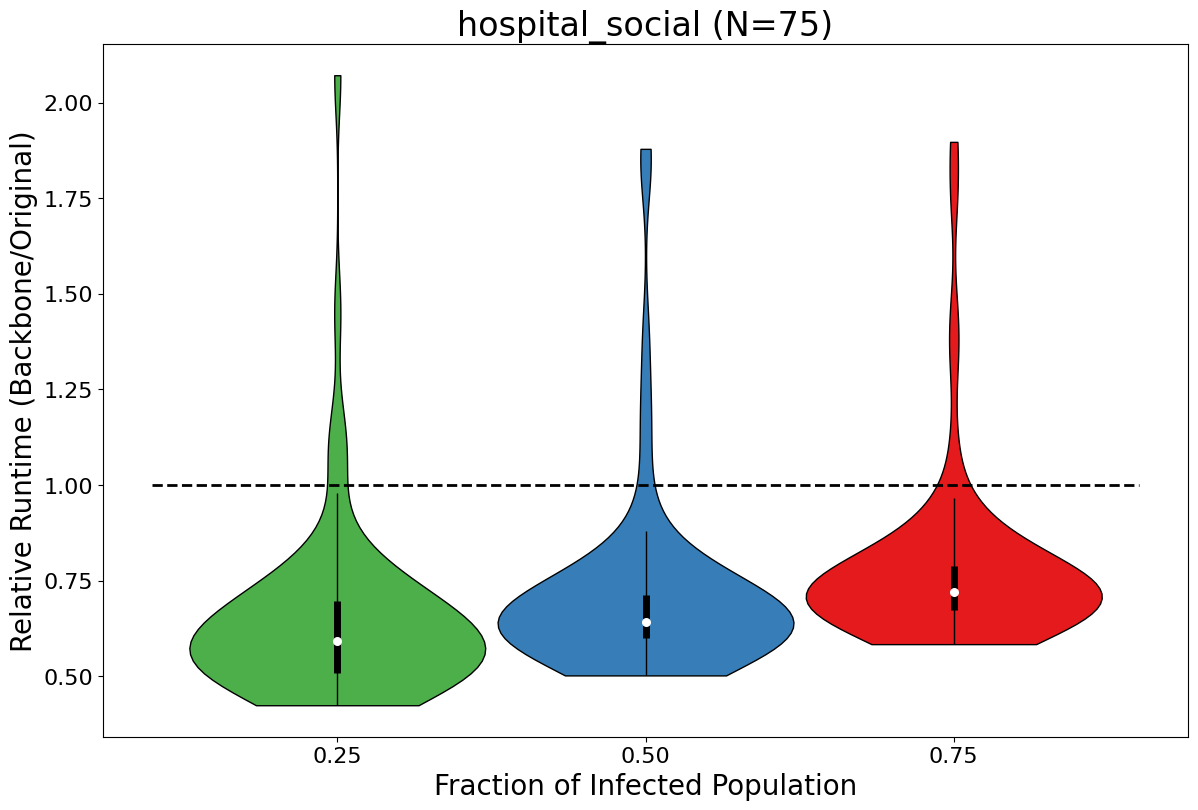

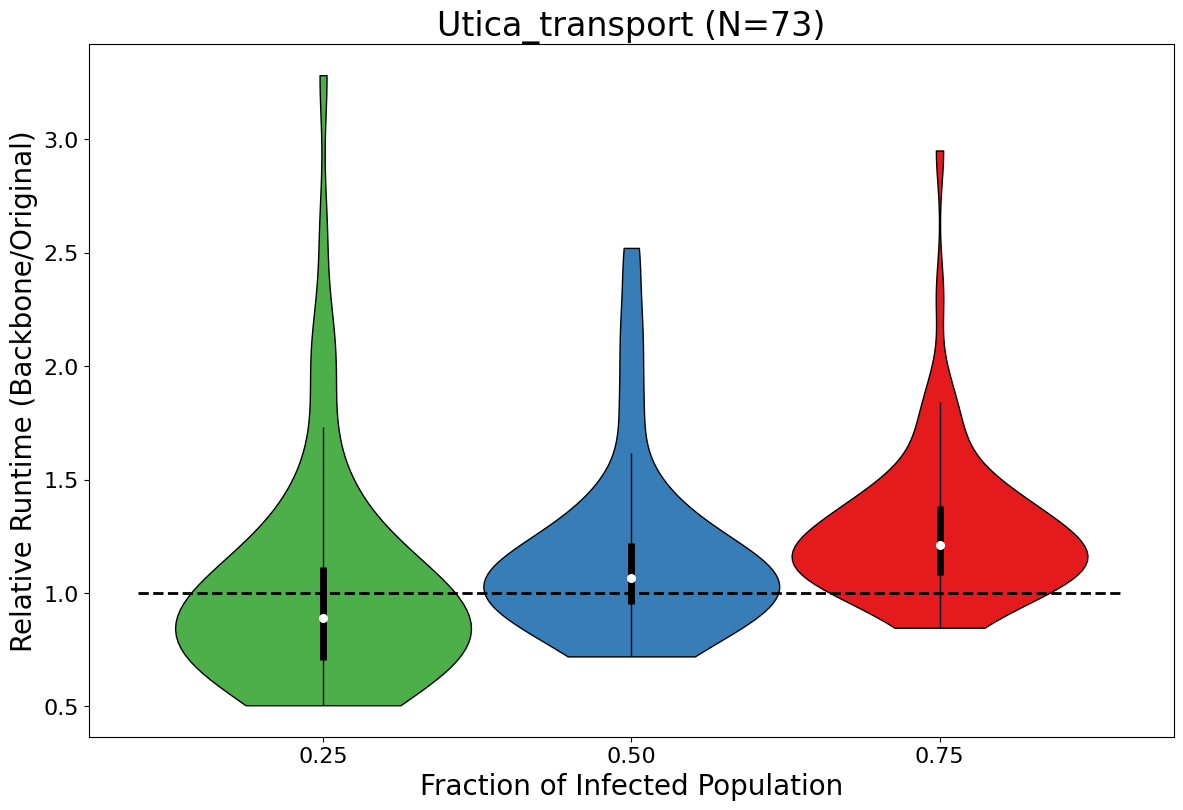

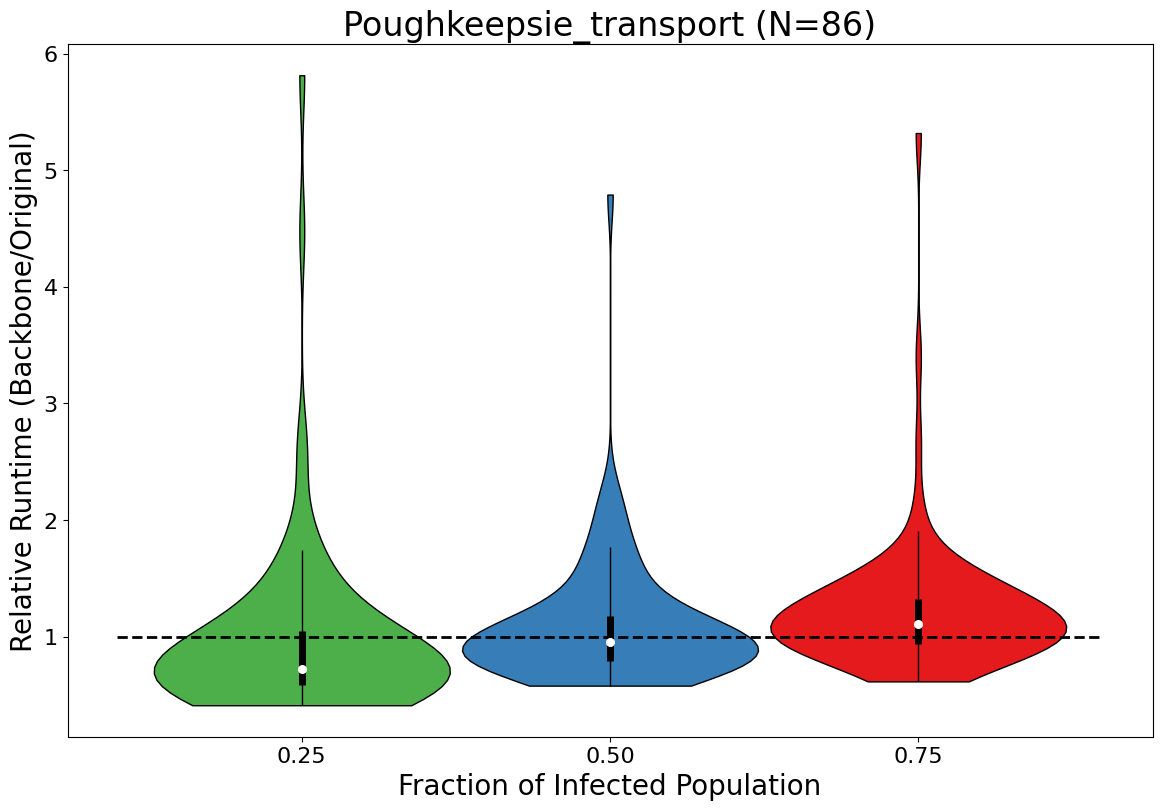

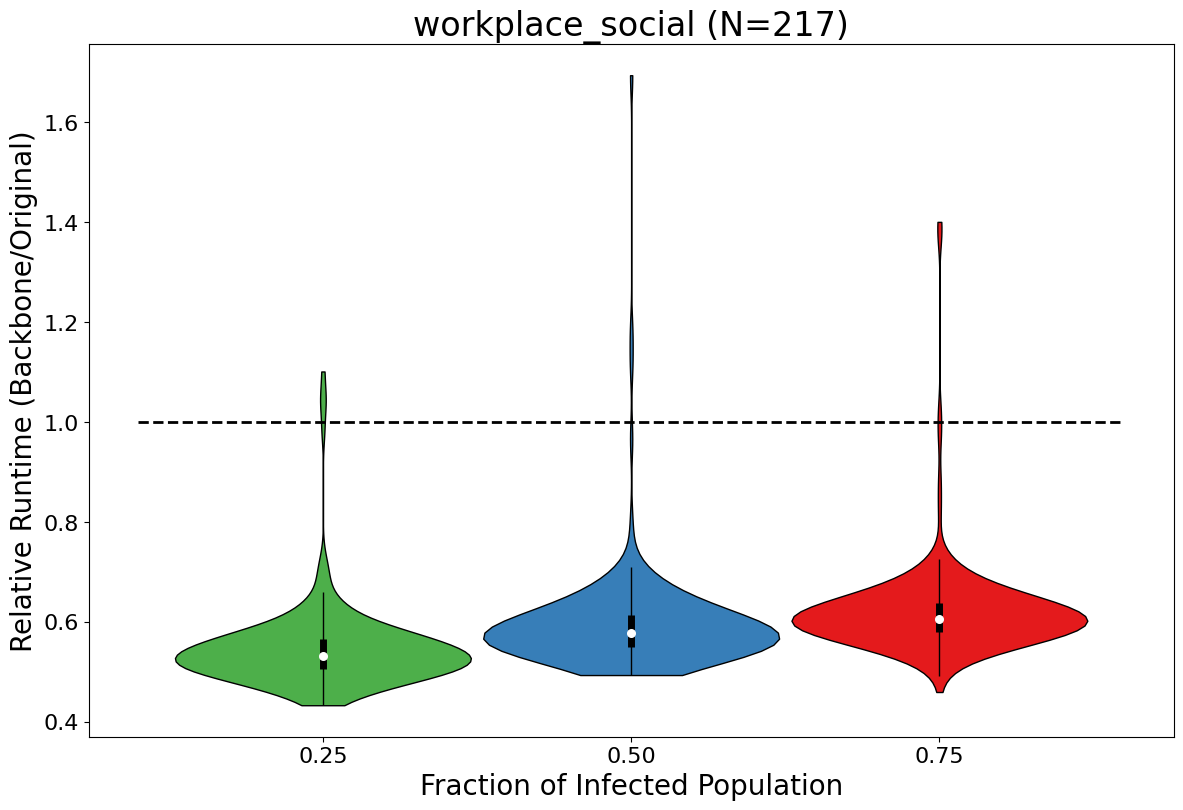

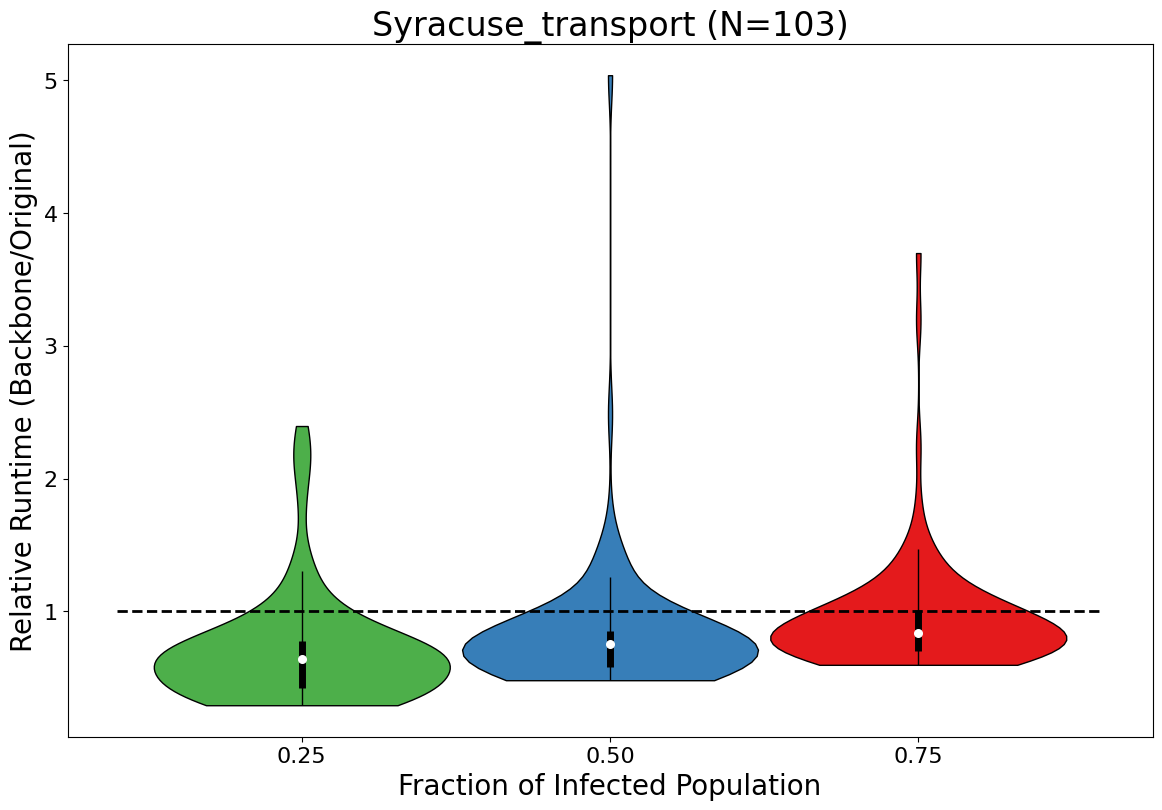

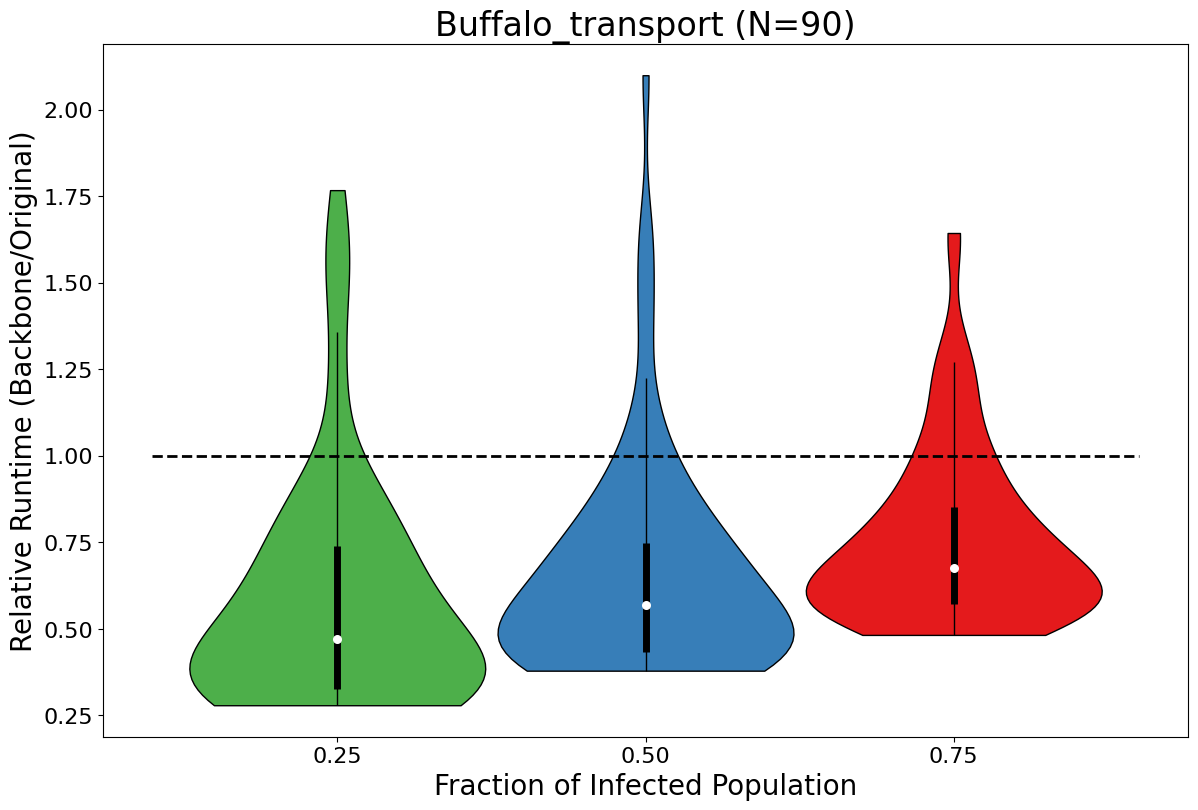

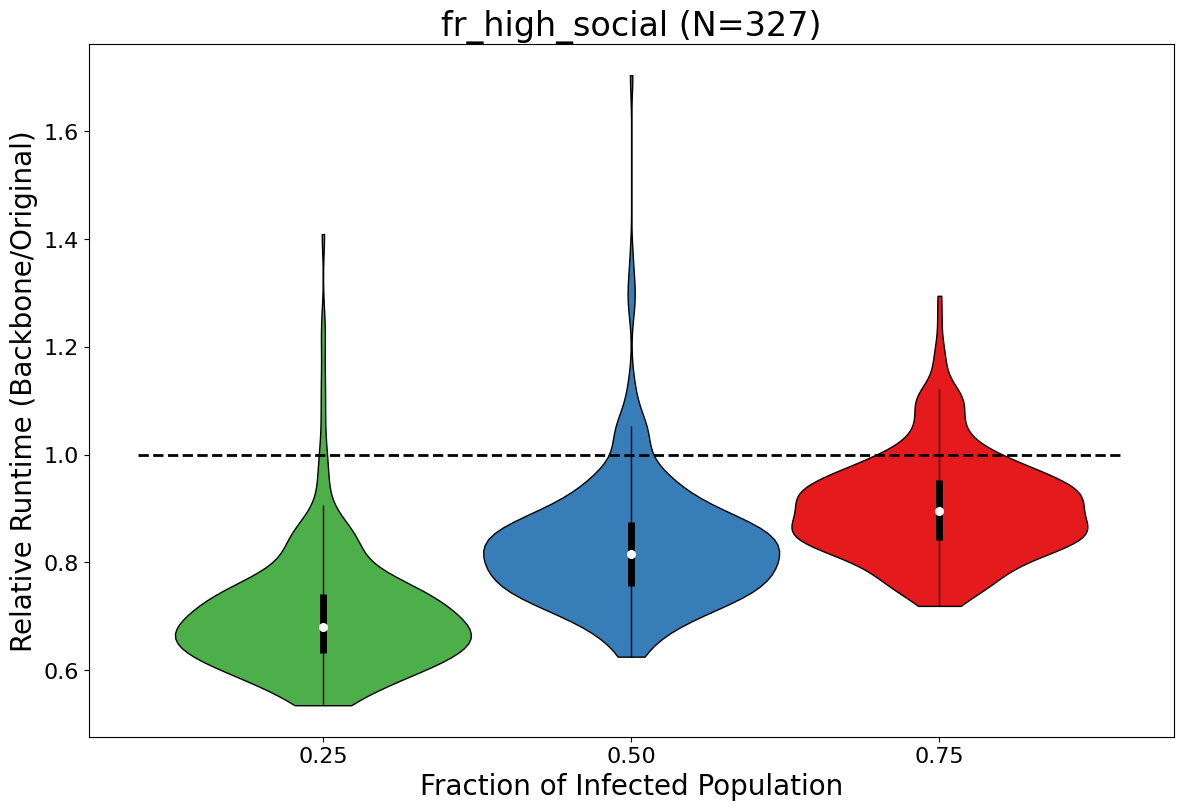

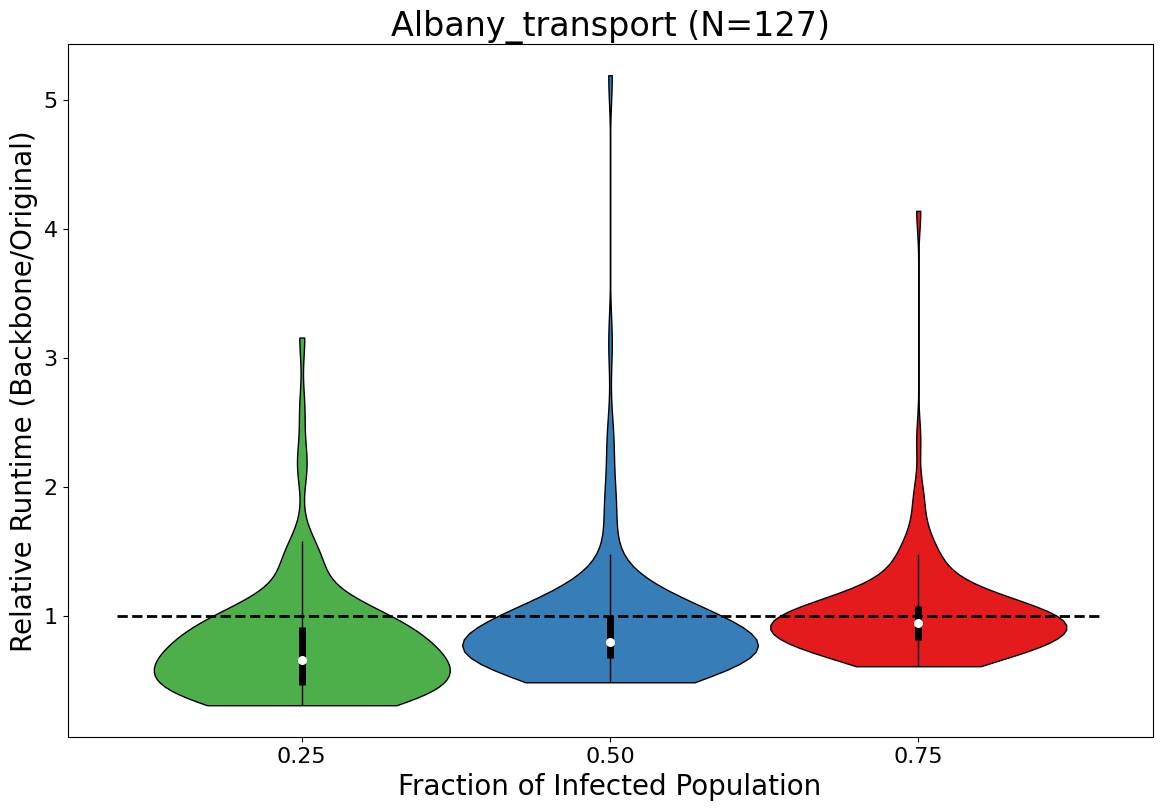

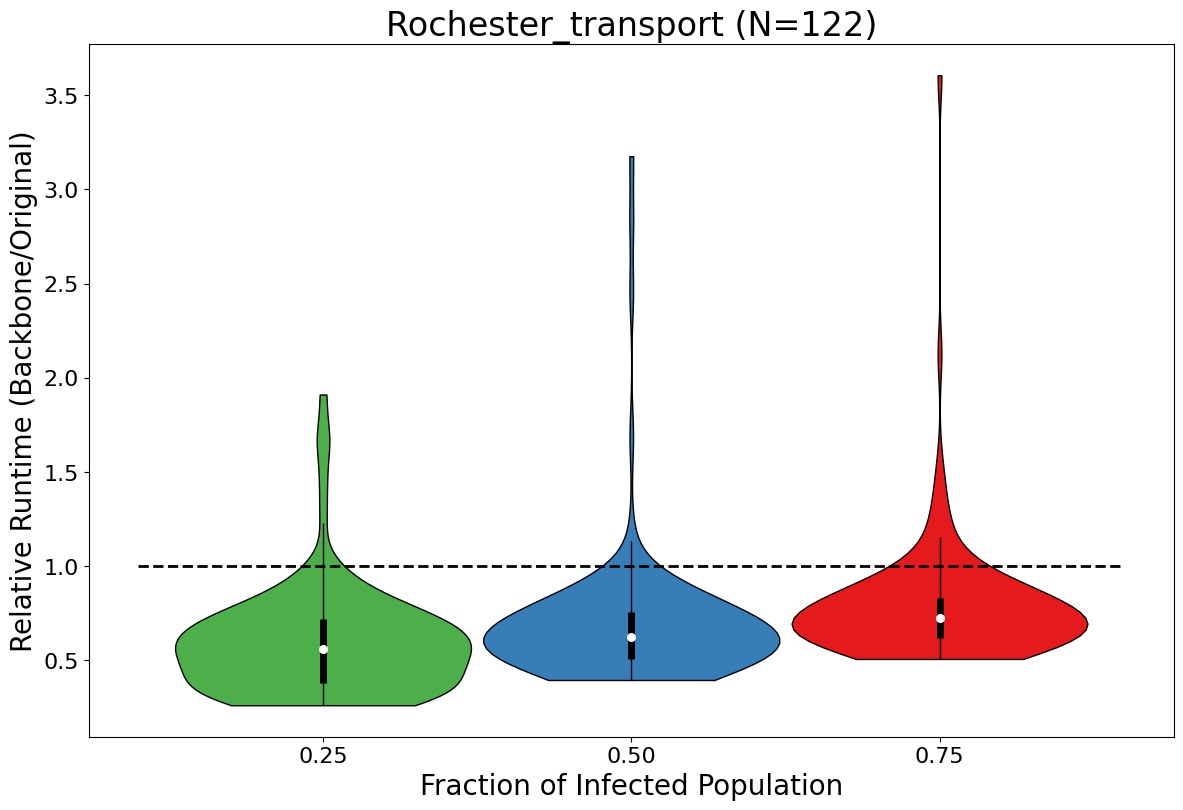

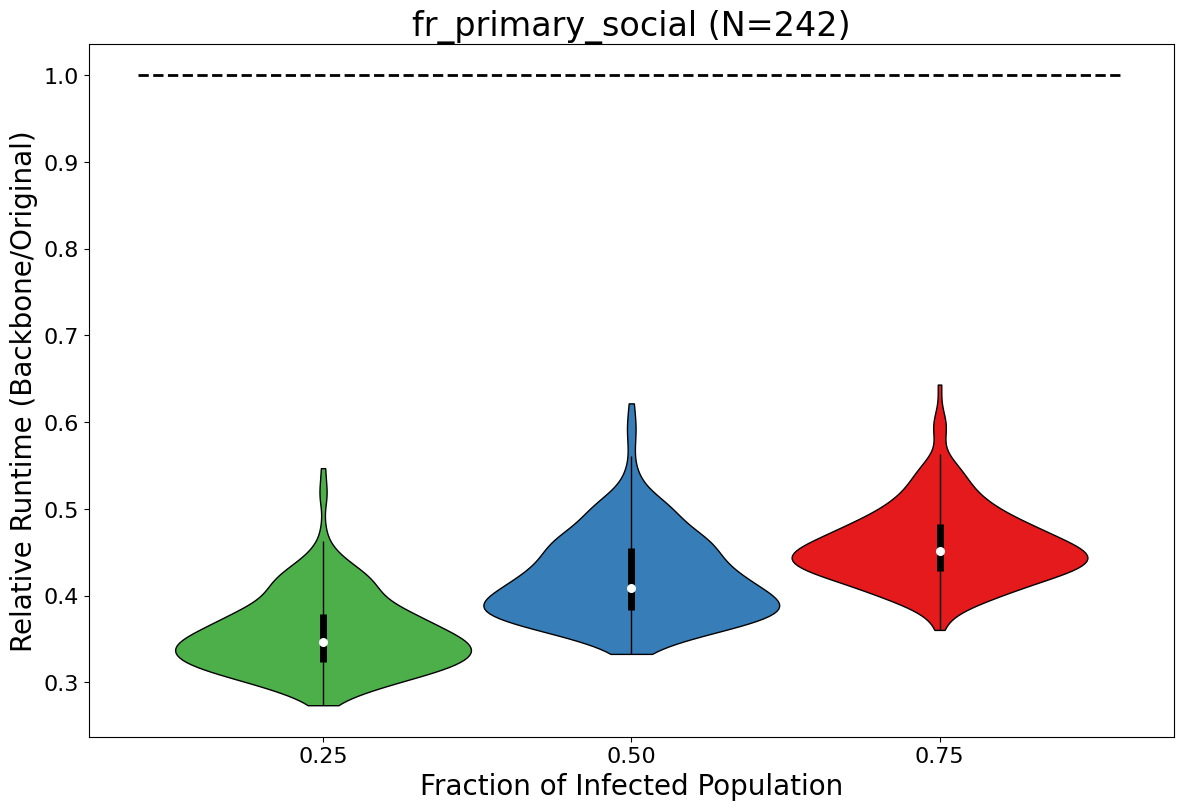

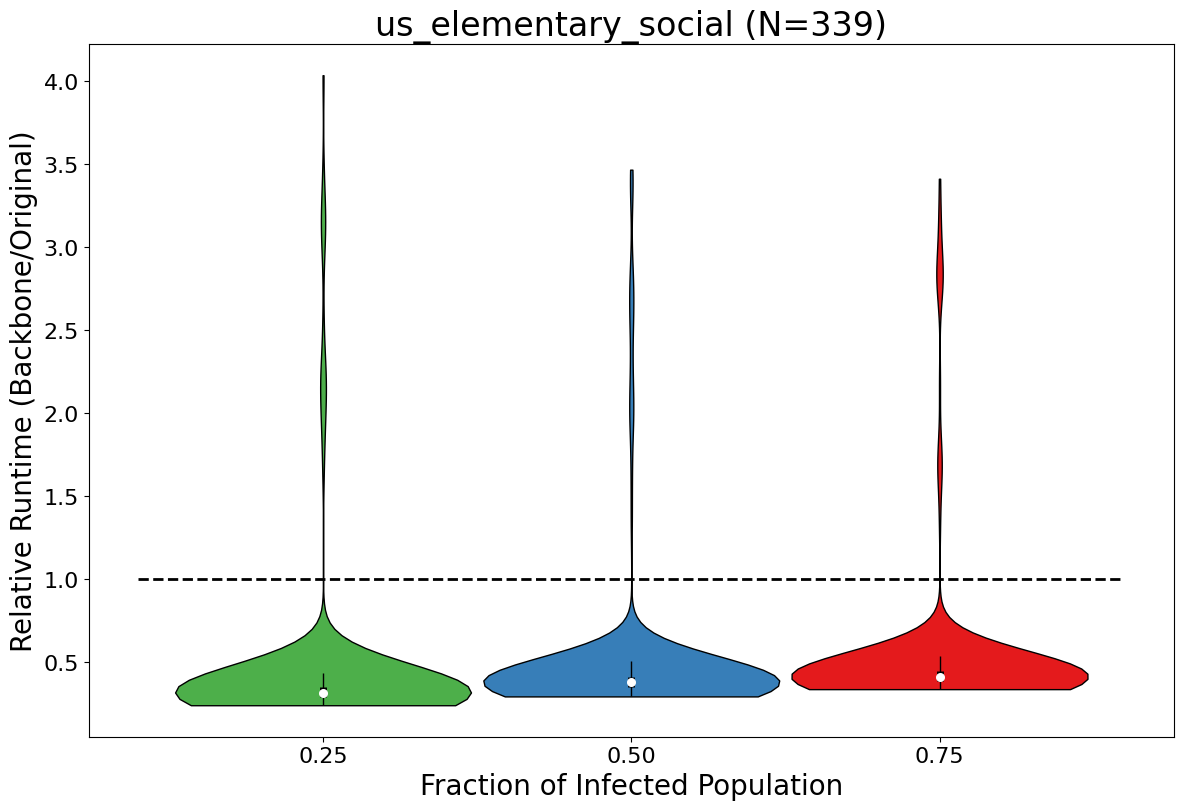

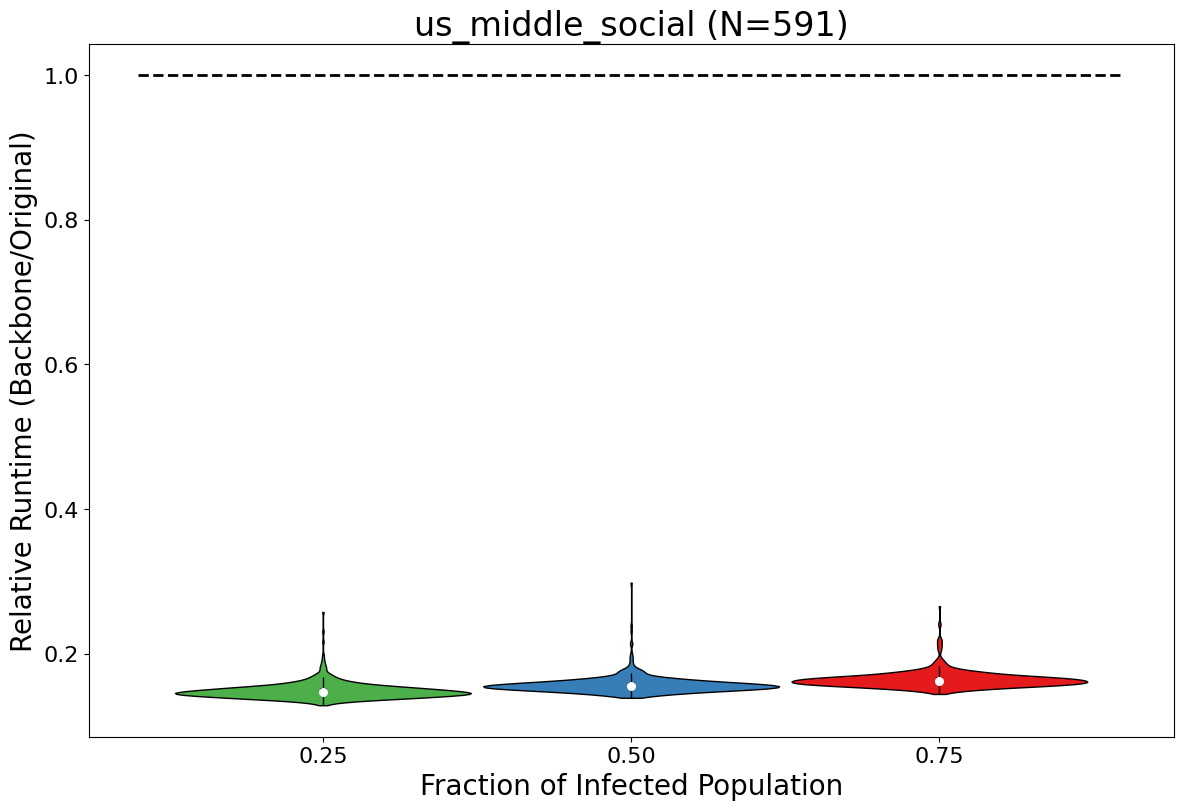

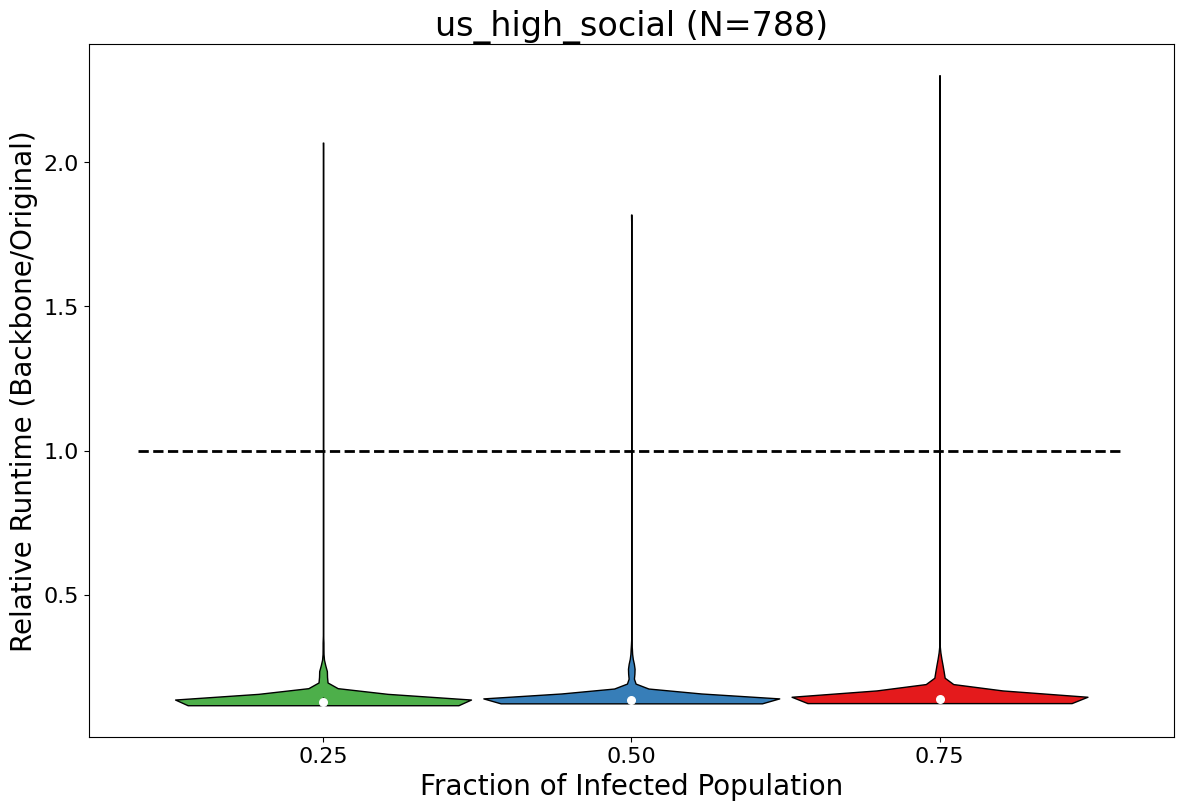

In [17]:
colors = ["#4daf4a", "#377eb8", "#e41a1c"]

for fname in sorted_files:
    fig, ax = plt.subplots(figsize=(14, 9))
    for idx, nfrac in enumerate([0.25, 0.5, 0.75]):
        rFile = f'exec_time/relative_times_{int(100*nfrac)}/{fname}'
        df = pd.read_csv(rFile, header=None, names=['node', 'time'])
        
        parts = ax.violinplot(df['time'], positions=[nfrac], widths=0.24, showmeans=False, showmedians=False, showextrema=False)
        
        for pc in parts['bodies']:
            pc.set_facecolor(colors[idx])
            pc.set_edgecolor('black')
            pc.set_alpha(1)
        
        quartile1, medians, quartile3 = np.percentile(df['time'], [25, 50, 75])
        whiskers = adjacent_values(df['time'], quartile1, quartile3) 
        whiskers_min, whiskers_max = whiskers[0], whiskers[1]
        
        ax.scatter([nfrac], [medians], marker='o', color='white', s=30, zorder=3)
        ax.vlines(nfrac, quartile1, quartile3, color='k', linestyle='-', lw=5)
        ax.vlines(nfrac, whiskers_min, whiskers_max, color='k', linestyle='-', lw=1)

    
    ax.hlines(1.0, 0.1, 0.9, color='k', linestyle='--', lw=2)
        
    ax.set_xticks([0.25, 0.5, 0.75])
    ax.tick_params(labelsize=16)
    
    ax.set_xlabel('Fraction of Infected Population', fontsize=20)
    ax.set_ylabel('Relative Runtime (Backbone/Original)', fontsize=20)
    
    ax.set_title(f'{fname[:-4]} (N={len(df)})', fontsize=24)
    
    
    
    wFile = f'exec_time/relative_time_plots/{fname[:-4]}.png'
    ensurePathExists(wFile)
    #plt.show()
    plt.savefig(wFile, dpi=300)